## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.read_csv("automobileEDA_dirty_training.csv")
display(data.head())
display(data.info())|

NameError: name 'pd' is not defined

In [ ]:
inspect_data=['symboling','normalized-losses','curb-weight','engine-size','diesel','gas']

for ins in inspect_data:
    display(data[ins].value_counts())

symboling
 0    67
 1    53
 2    33
 3    27
-1    22
-2     3
Name: count, dtype: int64

normalized-losses
122    43
161    11
91      8
150     7
104     6
128     6
134     6
148     5
85      5
103     5
168     5
74      5
102     5
65      5
94      5
95      5
118     4
106     4
93      4
137     3
101     3
115     3
125     3
108     3
154     3
83      3
164     2
158     2
192     2
188     2
81      2
110     2
145     2
113     2
129     2
153     2
194     2
119     2
89      2
87      2
197     2
121     1
98      1
78      1
107     1
142     1
231     1
186     1
77      1
90      1
256     1
Name: count, dtype: int64

curb-weight
1989    4
2385    4
1918    3
2275    3
2548    2
       ..
2952    1
3049    1
3012    1
3217    1
3062    1
Name: count, Length: 169, dtype: int64

engine-size
122    16
92     15
98     14
97     14
108    13
110    12
90     11
109     8
120     7
181     7
141     7
152     6
136     6
121     6
146     6
156     5
91      5
130     4
183     4
164     3
209     3
70      3
194     3
171     3
258     2
140     2
134     2
234     2
132     2
131     1
61      1
79      1
111     1
119     1
326     1
80      1
308     1
304     1
103     1
151     1
161     1
173     1
145     1
Name: count, dtype: int64

diesel
0    184
1     21
Name: count, dtype: int64

gas
1    184
0     21
Name: count, dtype: int64

In [ ]:
data_raw = data.copy()
categorical_column = list(data_raw.select_dtypes(include="str").columns)
categorical_column += ('symboling','diesel','gas')
print("------Categorical-------")
display(categorical_column)

print("------Numerical------")
numerical_column = list(data_raw.select_dtypes(include='number').columns)
numerical_column.remove('symboling')
numerical_column.remove('gas')
numerical_column.remove('diesel')
display(numerical_column)

------Categorical-------


['transaction_date',
 'make',
 'aspiration',
 'num-of-doors',
 'body-style',
 'drive-wheels',
 'engine-location',
 'engine-type',
 'num-of-cylinders',
 'fuel-system',
 'horsepower-binned',
 'symboling',
 'diesel',
 'gas']

------Numerical------


['normalized-losses',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-size',
 'bore',
 'stroke',
 'compression-ratio',
 'horsepower',
 'peak-rpm',
 'city-mpg',
 'highway-mpg',
 'price',
 'city-L/100km']

### Cleansing Categorical Data 

In [ ]:
for category in categorical_column:
    data_raw[category] = data_raw[category].astype("str").str.lower().str.strip()

data_raw.head()    

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,01-03-2025,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,04-jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


In [ ]:
data_raw["transaction_date"] = pd.to_datetime(data_raw['transaction_date'],dayfirst=True,format="mixed")
data_raw.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,2025-01-02,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,2025-03-01,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,2025-01-04,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-05-01,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


In [ ]:
for category in categorical_column:
    data_raw[category] = data_raw[category].fillna(data_raw[category].mode()[0])

data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_date   205 non-null    datetime64[us]
 1   symboling          205 non-null    str           
 2   normalized-losses  205 non-null    int64         
 3   make               205 non-null    str           
 4   aspiration         205 non-null    str           
 5   num-of-doors       205 non-null    str           
 6   body-style         205 non-null    str           
 7   drive-wheels       205 non-null    str           
 8   engine-location    205 non-null    str           
 9   wheel-base         205 non-null    float64       
 10  length             205 non-null    float64       
 11  width              205 non-null    float64       
 12  height             205 non-null    float64       
 13  curb-weight        205 non-null    int64         
 14  engine-type        20

### Cleansing Numerical Data

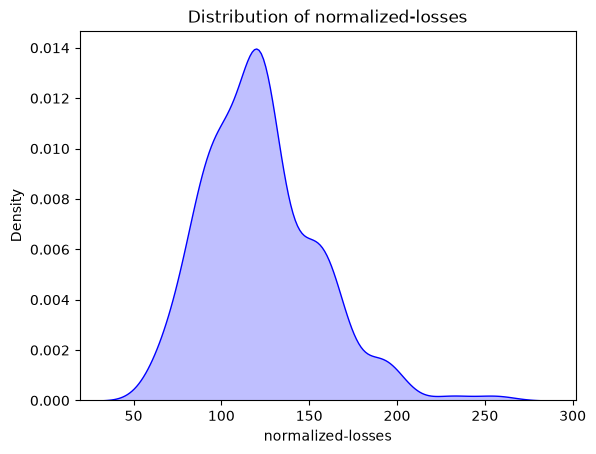

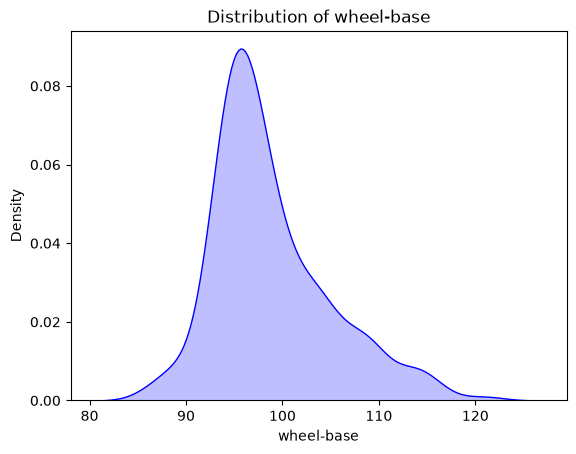

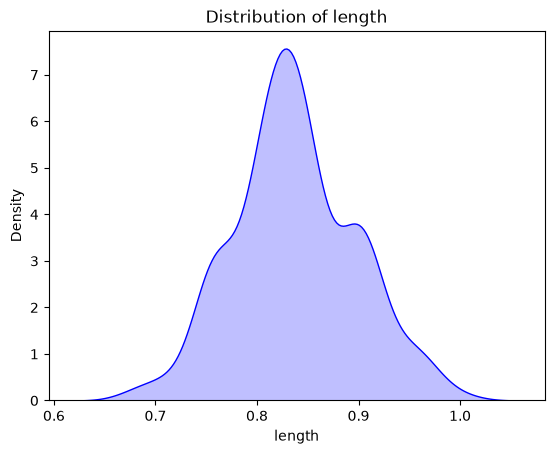

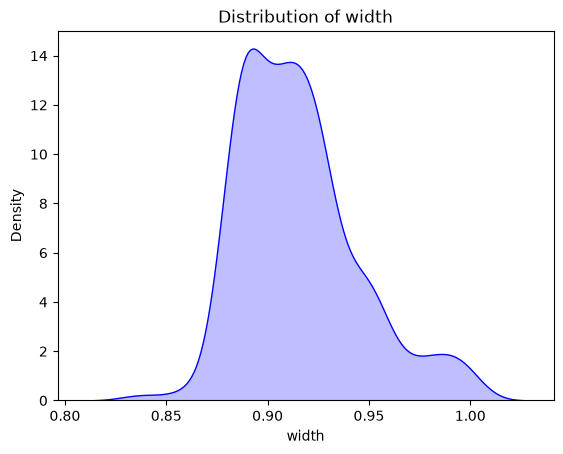

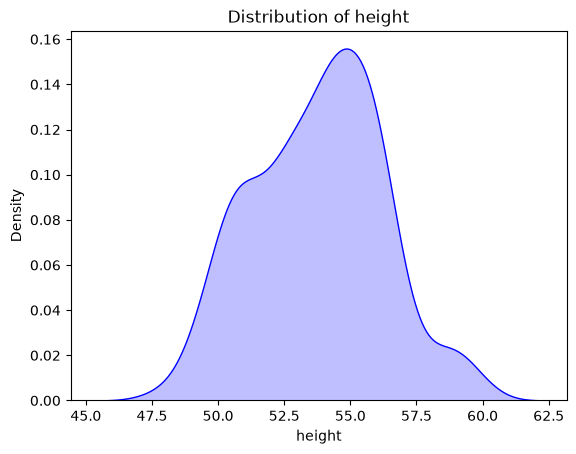

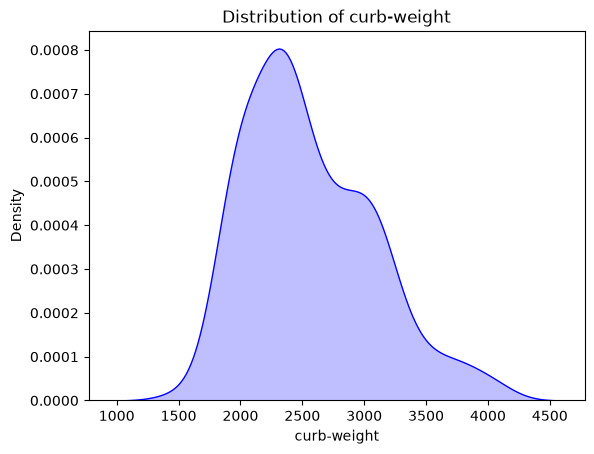

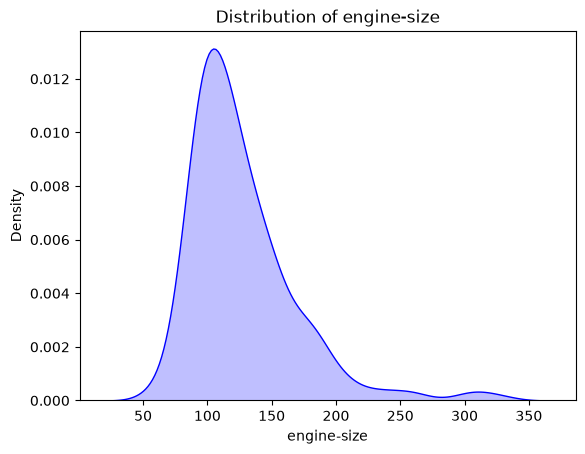

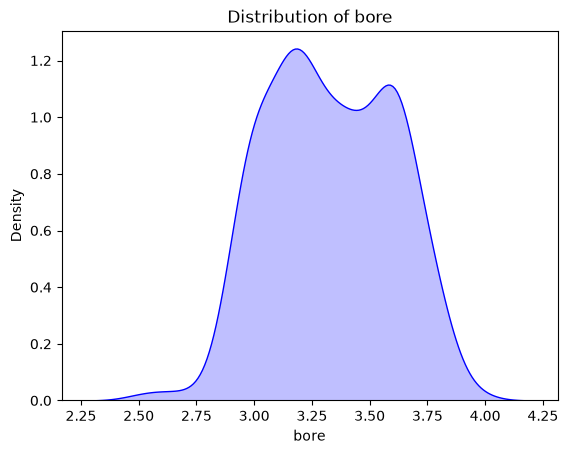

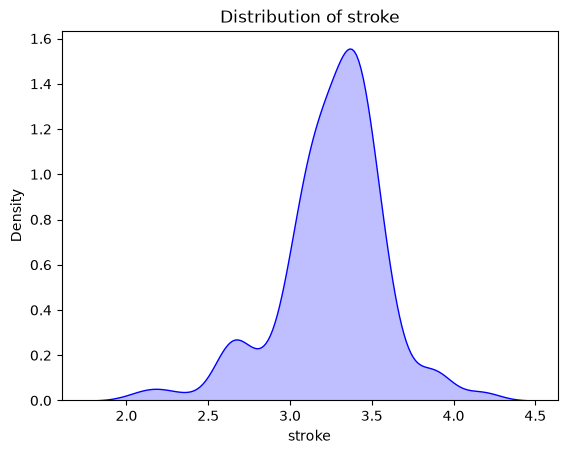

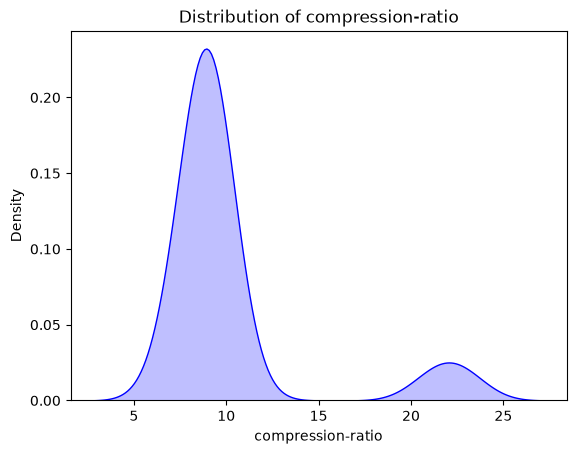

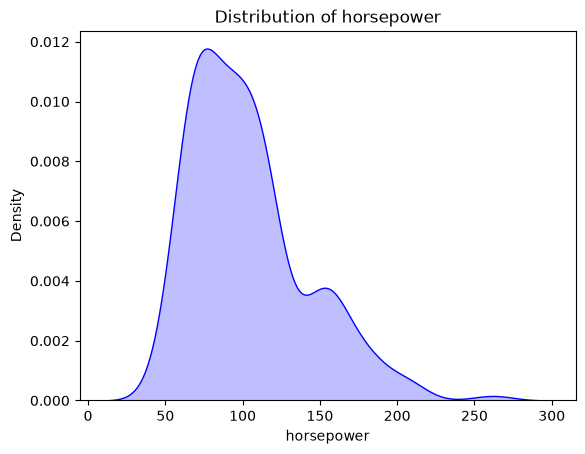

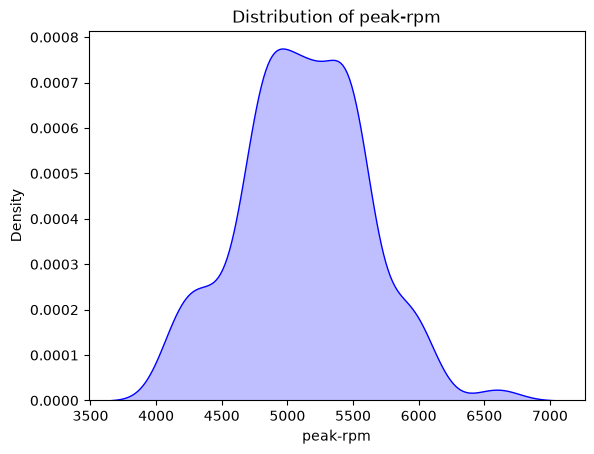

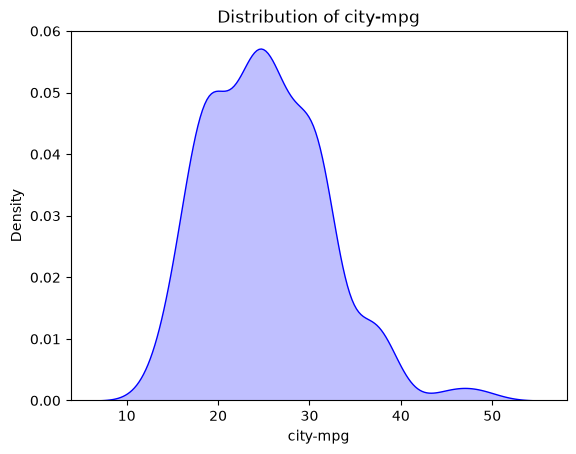

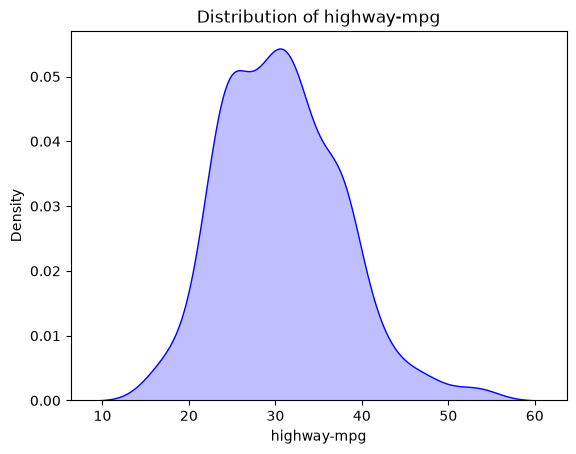

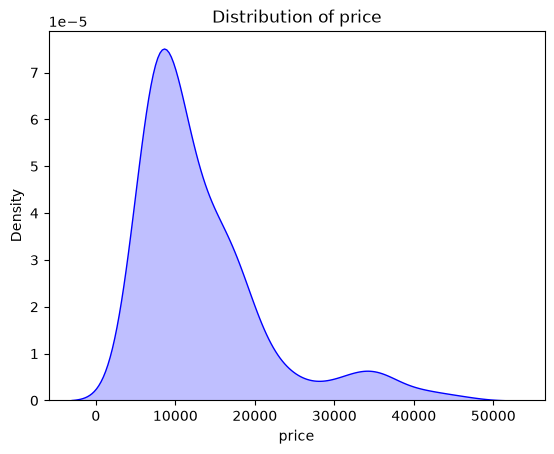

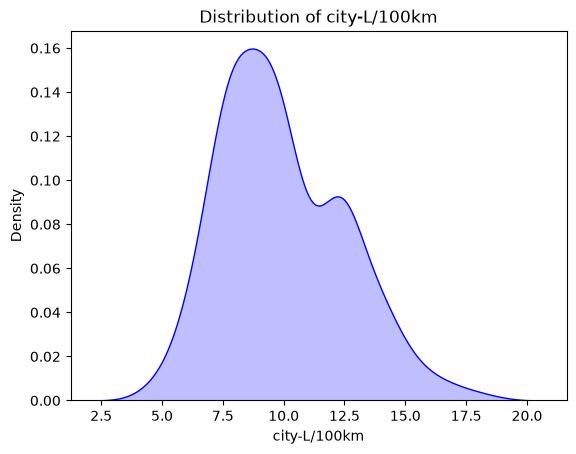

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for category in numerical_column:
    sns.kdeplot(data=data_raw, x=category, fill=True, color="blue")
    plt.title(f"Distribution of {category}")
    plt.show()